# QDArchive Classification Analysis
Interactive plots and tables for ISIC Rev.5 classification results across all three repositories.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

DB = "23692652-sq26.db"
conn = sqlite3.connect(DB)

REPO_NAMES = {1: "Zenodo", 10: "Harvard Dataverse"}
COLORS = ["#1F4E79", "#2E75B6", "#9DC3E6", "#BDD7EE"]

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})
print("Connected to DB:", DB)

Connected to DB: 23692652-sq26.db


## 1. Project Counts per Repository

,Repository,Total Projects
0,Harvard Dataverse,13650
1,Zenodo,39405


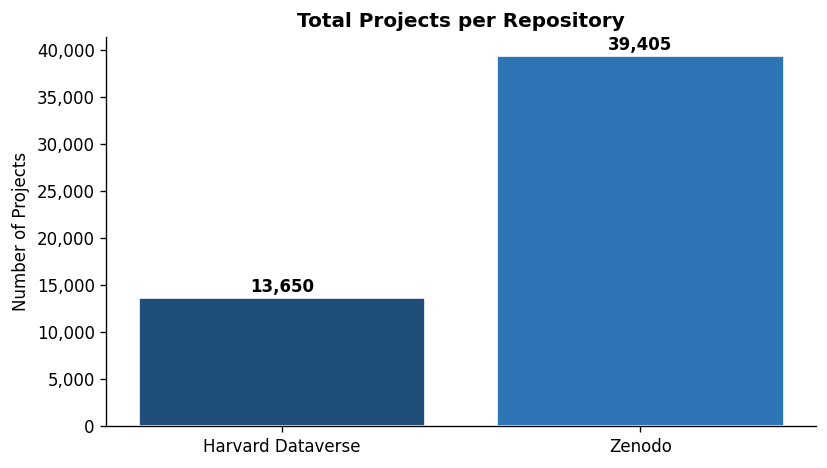

In [2]:
df_repos = pd.read_sql("""
    SELECT repository_id, type, COUNT(*) as count
    FROM projects
    GROUP BY repository_id, type
    ORDER BY repository_id, type
""", conn)

df_repos["repository"] = df_repos["repository_id"].map(REPO_NAMES)

summary = df_repos.groupby("repository")["count"].sum().reset_index()
summary.columns = ["Repository", "Total Projects"]
display(summary)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(summary["Repository"], summary["Total Projects"], color=COLORS[:3], edgecolor="white")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Total Projects per Repository")
ax.set_ylabel("Number of Projects")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 2. ISIC Section Distribution — Project Level (Ensemble Vote)

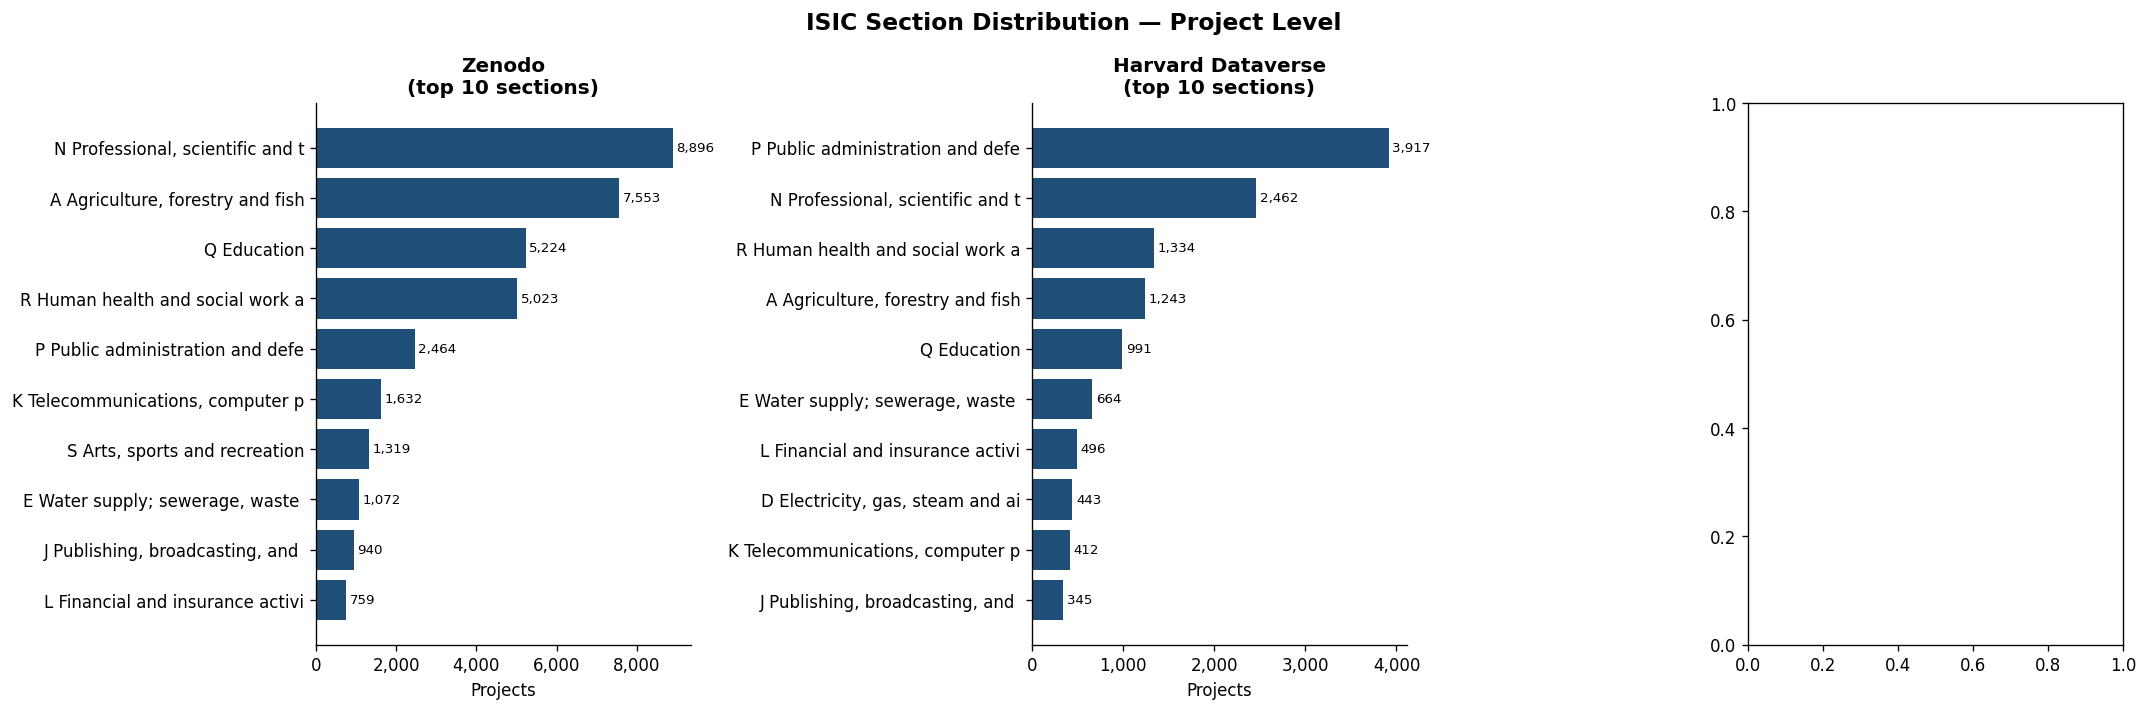

In [3]:
df_vote = pd.read_sql("""
    SELECT p.repository_id, cv.section, cv.section_name, COUNT(*) as count
    FROM classifications_vote cv
    JOIN projects p ON p.id = cv.project_id
    WHERE cv.section IS NOT NULL
    GROUP BY p.repository_id, cv.section, cv.section_name
    ORDER BY p.repository_id, count DESC
""", conn)

df_vote["repository"] = df_vote["repository_id"].map(REPO_NAMES)
df_vote["label"] = df_vote["section"] + " " + df_vote["section_name"].str[:30]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (repo_id, repo_name) in zip(axes, REPO_NAMES.items()):
    sub = df_vote[df_vote["repository_id"] == repo_id].nlargest(10, "count")
    if sub.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(repo_name)
        continue
    bars = ax.barh(sub["label"][::-1], sub["count"][::-1], color=COLORS[0])
    for bar in bars:
        ax.text(bar.get_width() + sub["count"].max()*0.01, bar.get_y() + bar.get_height()/2,
                f"{int(bar.get_width()):,}", va="center", fontsize=8)
    ax.set_title(f"{repo_name}\n(top 10 sections)")
    ax.set_xlabel("Projects")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("ISIC Section Distribution — Project Level", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Section Distribution Table — All Repos Combined

In [4]:
df_all = pd.read_sql("""
    SELECT cv.section, cv.section_name, COUNT(*) as total
    FROM classifications_vote cv
    WHERE cv.section IS NOT NULL
    GROUP BY cv.section, cv.section_name
    ORDER BY total DESC
""", conn)

df_all["share_%"] = (df_all["total"] / df_all["total"].sum() * 100).round(1)
df_all.columns = ["Section", "Section Name", "Projects", "Share %"]
display(df_all.style.bar(subset=["Projects"], color="#9DC3E6").format({"Projects": "{:,}", "Share %": "{:.1f}%"}))

,Section,Section Name,Projects,Share %
0,N,"Professional, scientific and technical activities","11,368",21.4%
1,A,"Agriculture, forestry and fishing","8,796",16.6%
2,P,Public administration and defence; compulsory social security,"6,381",12.0%
3,R,Human health and social work activities,"6,370",12.0%
4,Q,Education,"6,216",11.7%
5,K,"Telecommunications, computer programming, consultancy, computing infrastructure, and other information service activities","2,044",3.9%
6,E,"Water supply; sewerage, waste management and remediation activities","1,736",3.3%
7,S,"Arts, sports and recreation","1,455",2.7%
8,J,"Publishing, broadcasting, and content production and distribution activities","1,285",2.4%
9,L,Financial and insurance activities,"1,255",2.4%


## 4. Vote Confidence Distribution

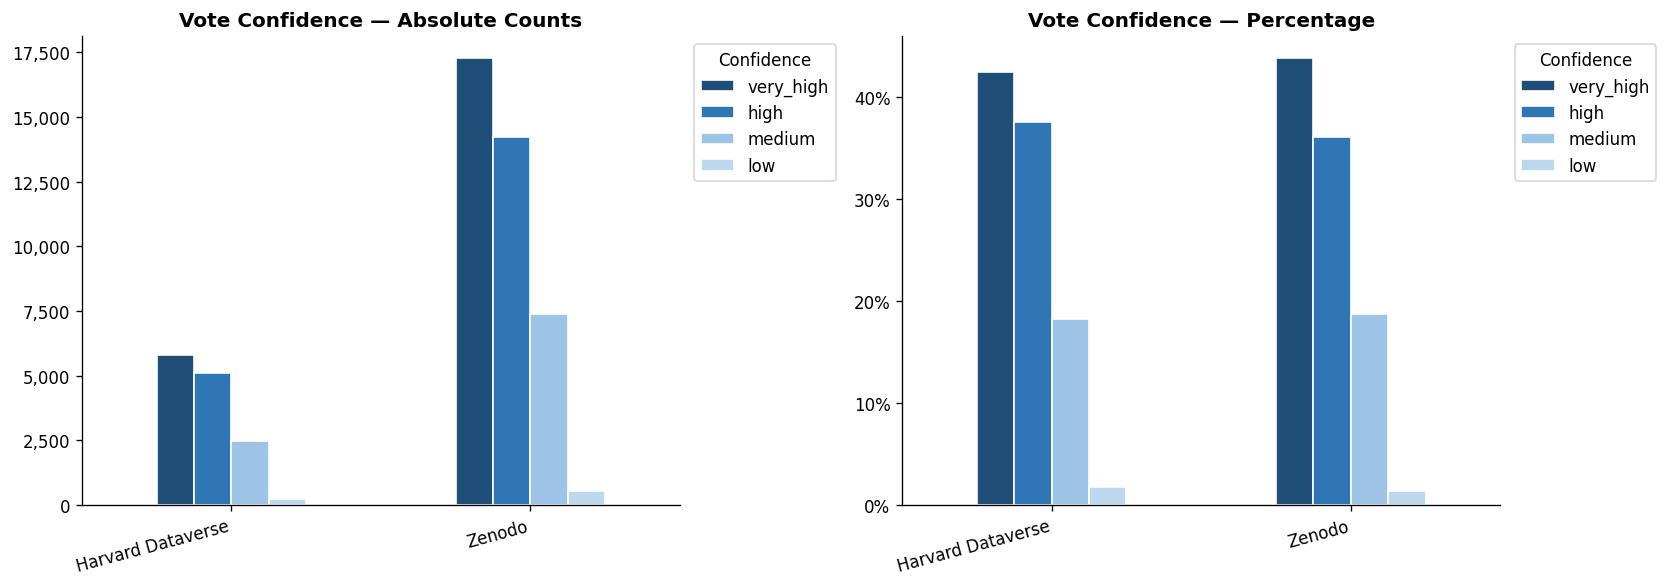

In [5]:
df_conf = pd.read_sql("""
    SELECT p.repository_id, cv.confidence, COUNT(*) as count
    FROM classifications_vote cv
    JOIN projects p ON p.id = cv.project_id
    GROUP BY p.repository_id, cv.confidence
""", conn)

df_conf["repository"] = df_conf["repository_id"].map(REPO_NAMES)
pivot = df_conf.pivot_table(index="repository", columns="confidence", values="count", fill_value=0)
order = [c for c in ["very_high","high","medium","low","very_low"] if c in pivot.columns]
pivot = pivot[order]

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot.plot(kind="bar", ax=axes[0], color=COLORS, edgecolor="white")
axes[0].set_title("Vote Confidence — Absolute Counts")
axes[0].set_xlabel("")
axes[0].set_xticklabels(pivot.index, rotation=15, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].spines[["top", "right"]].set_visible(False)

pivot_pct.plot(kind="bar", ax=axes[1], color=COLORS, edgecolor="white")
axes[1].set_title("Vote Confidence — Percentage")
axes[1].set_xlabel("")
axes[1].set_xticklabels(pivot_pct.index, rotation=15, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[1].spines[["top", "right"]].set_visible(False)

for ax in axes:
    ax.legend(title="Confidence", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 5. File-Level Classification — ISIC Section Distribution

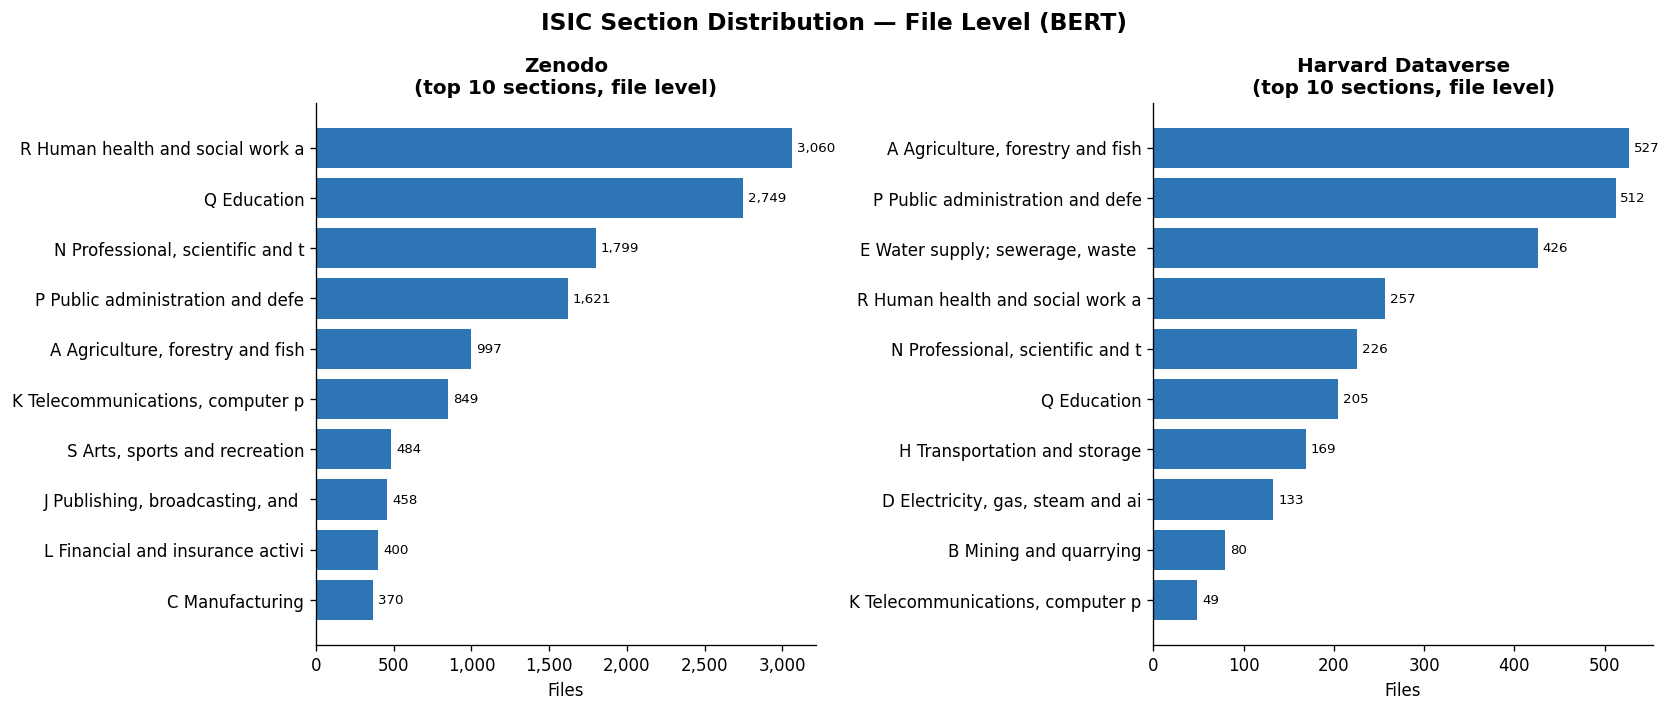

In [6]:
df_files = pd.read_sql("""
    SELECT p.repository_id, cf.section, cf.section_name, COUNT(*) as count
    FROM classifications_files cf
    JOIN projects p ON p.id = cf.project_id
    WHERE cf.section IS NOT NULL
    GROUP BY p.repository_id, cf.section, cf.section_name
    ORDER BY p.repository_id, count DESC
""", conn)

df_files["repository"] = df_files["repository_id"].map(REPO_NAMES)
df_files["label"] = df_files["section"] + " " + df_files["section_name"].str[:30]

repos_with_files = df_files["repository_id"].unique()
fig, axes = plt.subplots(1, len(repos_with_files), figsize=(7*len(repos_with_files), 6))
if len(repos_with_files) == 1:
    axes = [axes]

for ax, repo_id in zip(axes, repos_with_files):
    sub = df_files[df_files["repository_id"] == repo_id].nlargest(10, "count")
    bars = ax.barh(sub["label"][::-1], sub["count"][::-1], color=COLORS[1])
    for bar in bars:
        ax.text(bar.get_width() + sub["count"].max()*0.01, bar.get_y() + bar.get_height()/2,
                f"{int(bar.get_width()):,}", va="center", fontsize=8)
    ax.set_title(f"{REPO_NAMES[repo_id]}\n(top 10 sections, file level)")
    ax.set_xlabel("Files")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("ISIC Section Distribution — File Level (BERT)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. File-Level Confidence Distribution

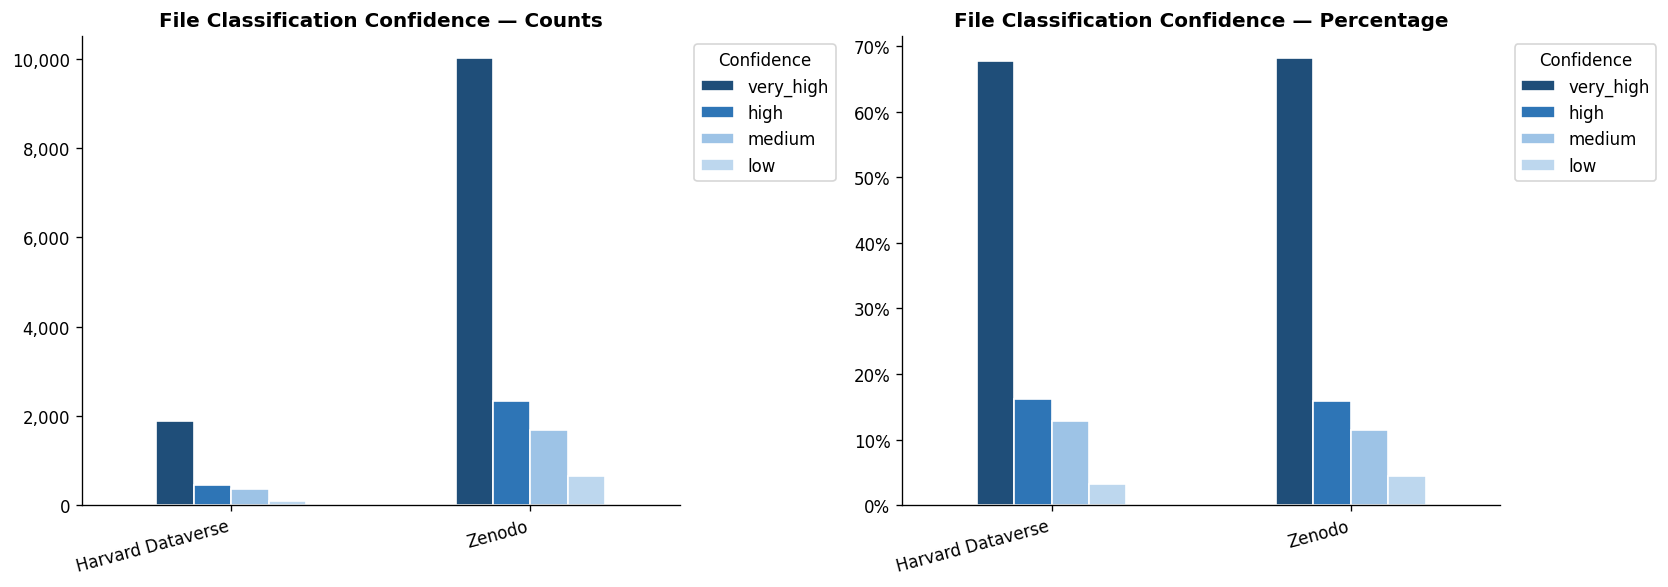

In [7]:
df_fconf = pd.read_sql("""
    SELECT p.repository_id, cf.confidence, COUNT(*) as count
    FROM classifications_files cf
    JOIN projects p ON p.id = cf.project_id
    GROUP BY p.repository_id, cf.confidence
""", conn)

df_fconf["repository"] = df_fconf["repository_id"].map(REPO_NAMES)
pivot_f = df_fconf.pivot_table(index="repository", columns="confidence", values="count", fill_value=0)
order_f = [c for c in ["very_high","high","medium","low","very_low"] if c in pivot_f.columns]
pivot_f = pivot_f[order_f]
pivot_f_pct = pivot_f.div(pivot_f.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_f.plot(kind="bar", ax=axes[0], color=COLORS, edgecolor="white")
axes[0].set_title("File Classification Confidence — Counts")
axes[0].set_xlabel("")
axes[0].set_xticklabels(pivot_f.index, rotation=15, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].spines[["top", "right"]].set_visible(False)

pivot_f_pct.plot(kind="bar", ax=axes[1], color=COLORS, edgecolor="white")
axes[1].set_title("File Classification Confidence — Percentage")
axes[1].set_xlabel("")
axes[1].set_xticklabels(pivot_f_pct.index, rotation=15, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[1].spines[["top", "right"]].set_visible(False)

for ax in axes:
    ax.legend(title="Confidence", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 7. Project vs File Classification Agreement

In [8]:
df_agree = pd.read_sql("""
    SELECT
        p.repository_id,
        SUM(CASE WHEN cv.section = cf_top.section THEN 1 ELSE 0 END) as agree,
        COUNT(*) as total
    FROM projects p
    JOIN classifications_vote cv ON cv.project_id = p.id
    JOIN (
        SELECT project_id, section, COUNT(*) as cnt
        FROM classifications_files
        GROUP BY project_id, section
        HAVING cnt = (SELECT MAX(cnt2) FROM
            (SELECT COUNT(*) as cnt2 FROM classifications_files cf2
             WHERE cf2.project_id = classifications_files.project_id
             GROUP BY cf2.section))
    ) cf_top ON cf_top.project_id = p.id
    GROUP BY p.repository_id
""", conn)

df_agree["repository"] = df_agree["repository_id"].map(REPO_NAMES)
df_agree["agree_%"] = (df_agree["agree"] / df_agree["total"] * 100).round(1)
df_agree[["repository", "agree", "total", "agree_%"]].columns = ["Repository", "Agree", "Total", "Agreement %"]
display(df_agree[["repository", "agree", "total", "agree_%"]].rename(columns={
    "repository": "Repository", "agree": "Agree", "total": "Total", "agree_%": "Agreement %"
}))

,Repository,Agree,Total,Agreement %
0,Zenodo,10555,13064,80.8
1,Harvard Dataverse,1053,1326,79.4


## 8. Top ISIC Divisions (2-digit, project level)

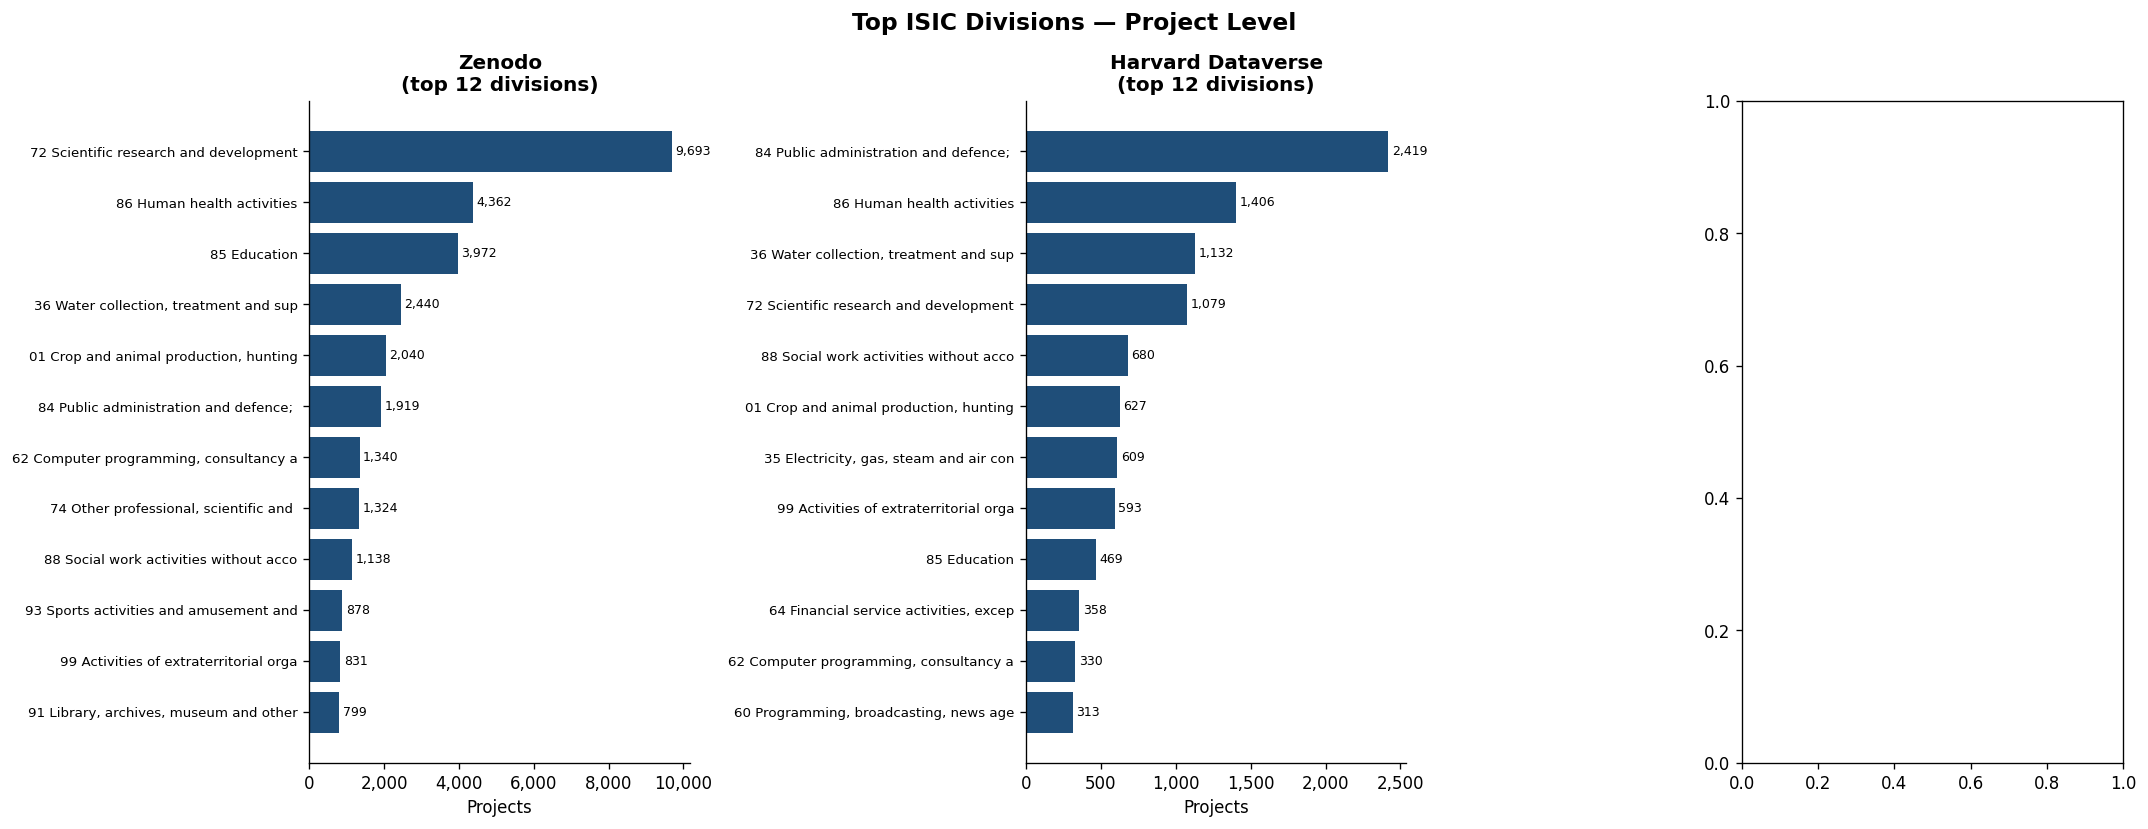

In [9]:
df_div = pd.read_sql("""
    SELECT p.repository_id, cv.division, cv.division_name, COUNT(*) as count
    FROM classifications_vote cv
    JOIN projects p ON p.id = cv.project_id
    WHERE cv.division IS NOT NULL AND cv.division != ''
    GROUP BY p.repository_id, cv.division, cv.division_name
    ORDER BY p.repository_id, count DESC
""", conn)

df_div["repository"] = df_div["repository_id"].map(REPO_NAMES)
df_div["label"] = df_div["division"] + " " + df_div["division_name"].str[:35]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, (repo_id, repo_name) in zip(axes, REPO_NAMES.items()):
    sub = df_div[df_div["repository_id"] == repo_id].nlargest(12, "count")
    if sub.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(repo_name)
        continue
    bars = ax.barh(sub["label"][::-1], sub["count"][::-1], color=COLORS[0])
    for bar in bars:
        ax.text(bar.get_width() + sub["count"].max()*0.01, bar.get_y() + bar.get_height()/2,
                f"{int(bar.get_width()):,}", va="center", fontsize=7.5)
    ax.set_title(f"{repo_name}\n(top 12 divisions)")
    ax.set_xlabel("Projects")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Top ISIC Divisions — Project Level", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8b. Top ISIC Divisions — File Level

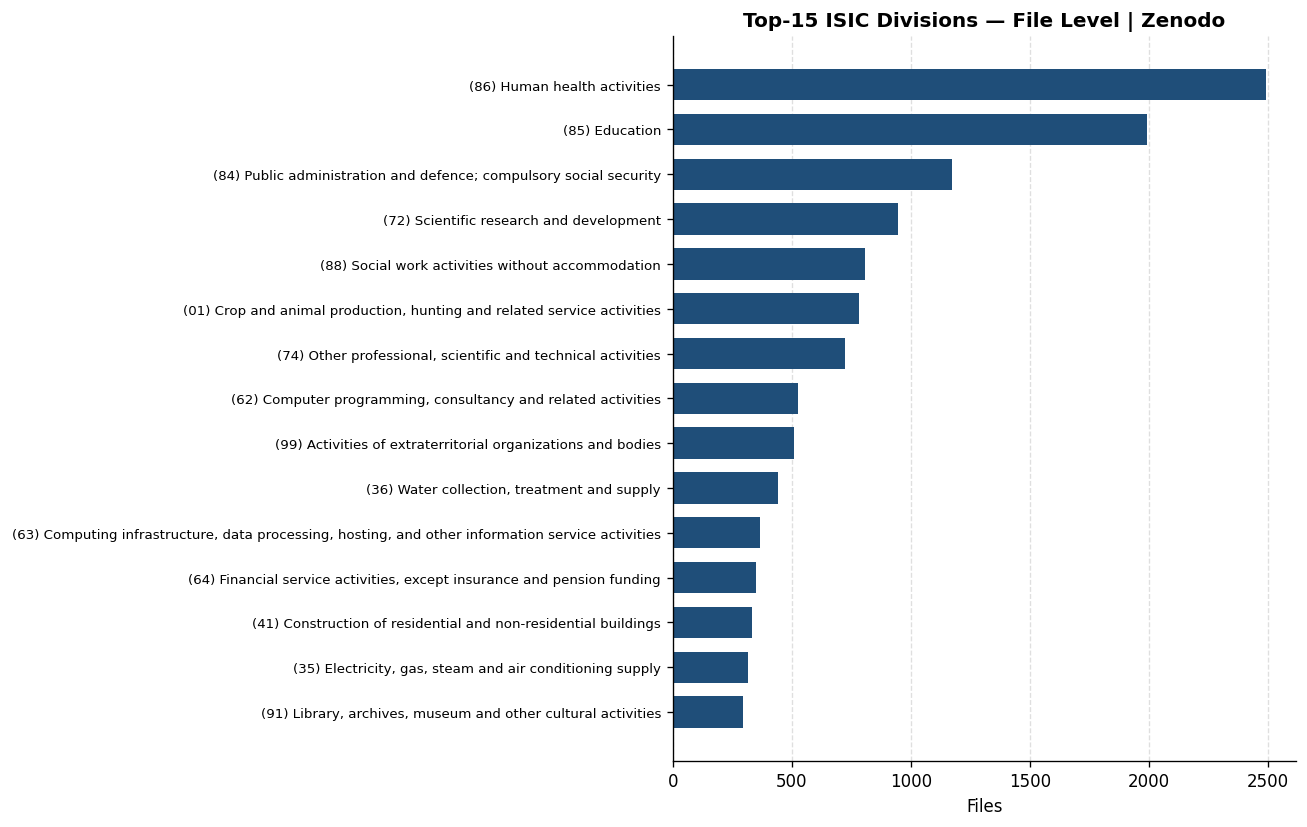

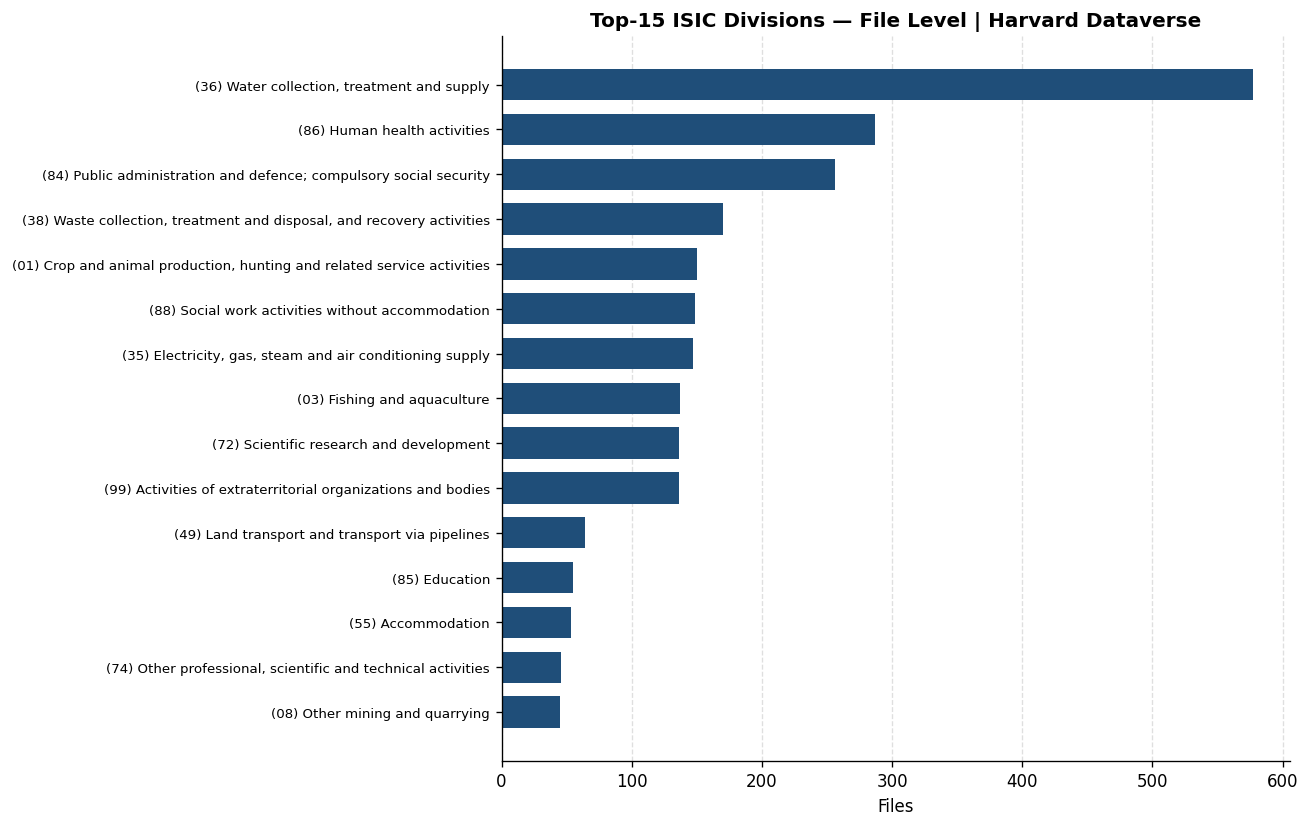


All repos — top 10 file-level divisions:


,division,division_name,count
62,86,Human health activities,2779
61,85,Education,2048
60,84,Public administration and defence; compulsory ...,1428
54,72,Scientific research and development,1080
29,36,"Water collection, treatment and supply",1019
64,88,Social work activities without accommodation,956
0,01,"Crop and animal production, hunting and relate...",932
56,74,"Other professional, scientific and technical a...",768
72,99,Activities of extraterritorial organizations a...,645
48,62,"Computer programming, consultancy and related ...",558


In [10]:
df_fdiv_a = pd.read_sql("""
    SELECT p.repository_id, cf.division, cf.division_name, COUNT(*) as count
    FROM classifications_files cf
    JOIN projects p ON p.id = cf.project_id
    WHERE cf.division IS NOT NULL
    GROUP BY p.repository_id, cf.division
    ORDER BY p.repository_id, count DESC
""", conn)
df_fdiv_a["repository"] = df_fdiv_a["repository_id"].map(REPO_NAMES)

for repo_id, repo_name in REPO_NAMES.items():
    sub = df_fdiv_a[df_fdiv_a["repository_id"] == repo_id].head(15).copy()
    if sub.empty:
        print(f"No file division data for {repo_name}")
        continue
    sub["label"] = sub.apply(lambda r: f"({r['division']}) {r['division_name']}", axis=1)
    sub = sub.sort_values("count", ascending=True)

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(range(len(sub)), sub["count"].values, color="#1F4E79", height=0.7)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub["label"].values, fontsize=8)
    ax.set_xlabel("Files")
    ax.set_title(f"Top-15 ISIC Divisions — File Level | {repo_name}", fontweight="bold")
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

print("\nAll repos — top 10 file-level divisions:")
display(df_fdiv_a.groupby(["division","division_name"])["count"]
        .sum().reset_index().sort_values("count", ascending=False).head(10))


## 9. Summary Table — All Metrics

In [11]:
summary_rows = []
for repo_id, repo_name in REPO_NAMES.items():
    n_projects = pd.read_sql(f"SELECT COUNT(*) as n FROM projects WHERE repository_id={repo_id}", conn).iloc[0,0]
    n_classified = pd.read_sql(f"SELECT COUNT(*) as n FROM classifications_vote cv JOIN projects p ON p.id=cv.project_id WHERE p.repository_id={repo_id}", conn).iloc[0,0]
    n_files_clf = pd.read_sql(f"SELECT COUNT(*) as n FROM classifications_files cf JOIN projects p ON p.id=cf.project_id WHERE p.repository_id={repo_id}", conn).iloc[0,0]
    top_section = pd.read_sql(f"""
        SELECT cv.section || ' - ' || cv.section_name as s
        FROM classifications_vote cv
        JOIN projects p ON p.id=cv.project_id
        WHERE p.repository_id={repo_id}
        GROUP BY cv.section ORDER BY COUNT(*) DESC LIMIT 1
    """, conn)
    top_s = top_section.iloc[0,0] if not top_section.empty else "N/A"
    summary_rows.append({
        "Repository": repo_name,
        "Total Projects": n_projects,
        "Classified Projects": n_classified,
        "Files Classified": n_files_clf,
        "Dominant ISIC Section": top_s
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary.style
    .format({"Total Projects": "{:,}", "Classified Projects": "{:,}", "Files Classified": "{:,}"})
    .set_properties(**{"text-align": "left"})
    .set_table_styles([{"selector": "th", "props": [("font-weight", "bold"), ("background-color", "#1F4E79"), ("color", "white")]}])
)

,Repository,Total Projects,Classified Projects,Files Classified,Dominant ISIC Section
0,Zenodo,"39,405","39,405","14,689","N - Professional, scientific and technical activities"
1,Harvard Dataverse,"13,650","13,650","2,787",P - Public administration and defence; compulsory social security


In [12]:
conn.close()
print("Done.")

Done.
